## Email Spam Detector

In [4]:
import numpy as np
import pandas as pd

In [6]:
df = pd.read_csv('spam.csv', encoding = "latin-1")

In [62]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
1296,ham,Sure! I am driving but will reach my destinati...,NaN,NaN,NaN
1720,ham,"Fighting with the world is easy, u either win ...",NaN,NaN,NaN
4311,ham,I keep ten rs in my shelf:) buy two egg.,NaN,NaN,NaN
546,ham,I know but you need to get hotel now. I just g...,NaN,NaN,NaN
1383,ham,Please reserve ticket on saturday eve from che...,NaN,NaN,NaN


In [68]:
df.shape

(5572, 5)

In [69]:
# 1. Data Cleaning
# 2. EDA
# 3. Text Preprocessing
# 4. Model building
# 5. Evalution
# 6. Improvement
# 7. Website
# 8. Deploy

## 1. Data Cleaning

In [70]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


In [71]:
df.drop(columns = ["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"], inplace = True)

In [72]:
df.sample(3)

,v1,v2
4634,ham,How come i din c Ì_... Yup i cut my hair...
553,ham,Ok. Every night take a warm bath drink a cup o...
4810,ham,E admin building there? I might b slightly ear...


In [76]:
# Renaming of columns

df.rename(columns={'v1' : 'target', 'v2' : 'text'}, inplace = True)

,target,text
103,ham,wow. You're right! I didn't mean to do that. I...
5204,ham,How come she can get it? Should b quite diff t...


In [79]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [80]:
df['target'] = encoder.fit_transform(df['target'])

In [82]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [84]:
# finding NULL values

df.isnull().sum()

target    0
text      0
dtype: int64

In [87]:
# check for duplicated values

df.duplicated().sum()

np.int64(403)

In [90]:
df = df.drop_duplicates(keep = 'first')

In [91]:
df.duplicated().sum()

np.int64(0)

In [92]:
df.shape

(5169, 2)

## 2. EDA

In [94]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

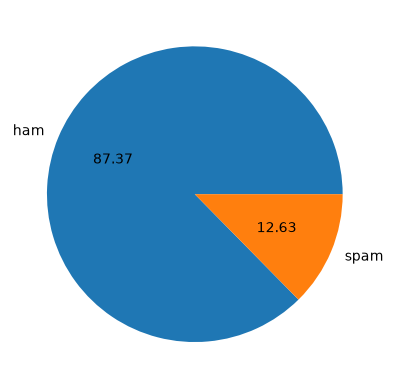

In [102]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(), labels = ['ham', 'spam'], autopct = "%0.2f")
plt.show()

In [103]:
# data is imbalanced



In [105]:
import nltk

In [106]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [108]:
df['num_character'] = df['text'].apply(len)

In [109]:
df.head()

,target,text,num_character
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [118]:
# num of word

df['num_word']=df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

'Ok lar... Joking wif u oni...'

In [120]:
df['num_sentence'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [123]:
df.sample(5)

,target,text,num_character,num_word,num_sentence
2475,0,Mm i am on the way to railway,29,8,1
4739,0,"I keep seeing weird shit and bein all \woah\"" ...",105,25,1
2516,0,Yes.i'm in office da:),22,7,1
1964,0,Honeybee Said: *I'm d Sweetest in d World* God...,158,42,2
2963,1,"Do you ever notice that when you're driving, a...",135,28,1


In [124]:
df[['num_character', 'num_word', 'num_sentence']].describe()

,num_character,num_word,num_sentence
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [125]:
df[df['target']==0][['num_character', 'num_word', 'num_sentence']].describe()

,num_character,num_word,num_sentence
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [127]:
df[df['target']==1][['num_character', 'num_word', 'num_sentence']].describe()

,num_character,num_word,num_sentence
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [130]:
import seaborn as sns

<Axes: xlabel='num_character', ylabel='Count'>

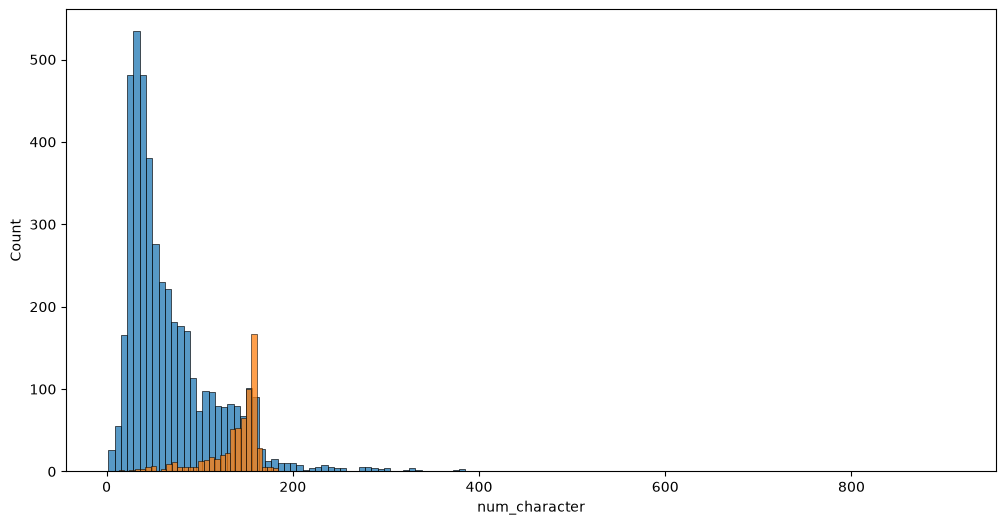

In [134]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target']==0]['num_character'])
sns.histplot(df[df['target']==1]['num_character'])

<Axes: xlabel='num_word', ylabel='Count'>

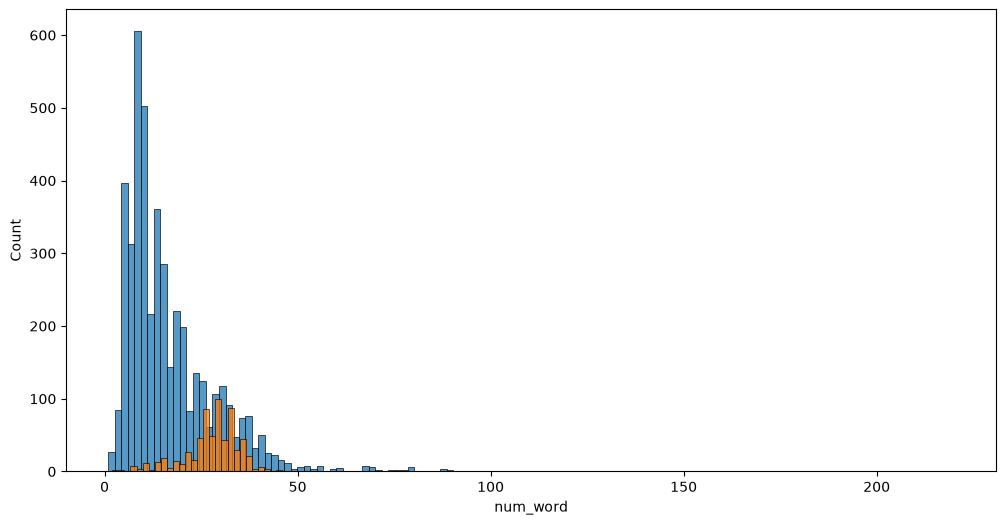

In [136]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target']==0]['num_word'])
sns.histplot(df[df['target']==1]['num_word'])

<Axes: xlabel='num_sentence', ylabel='Count'>

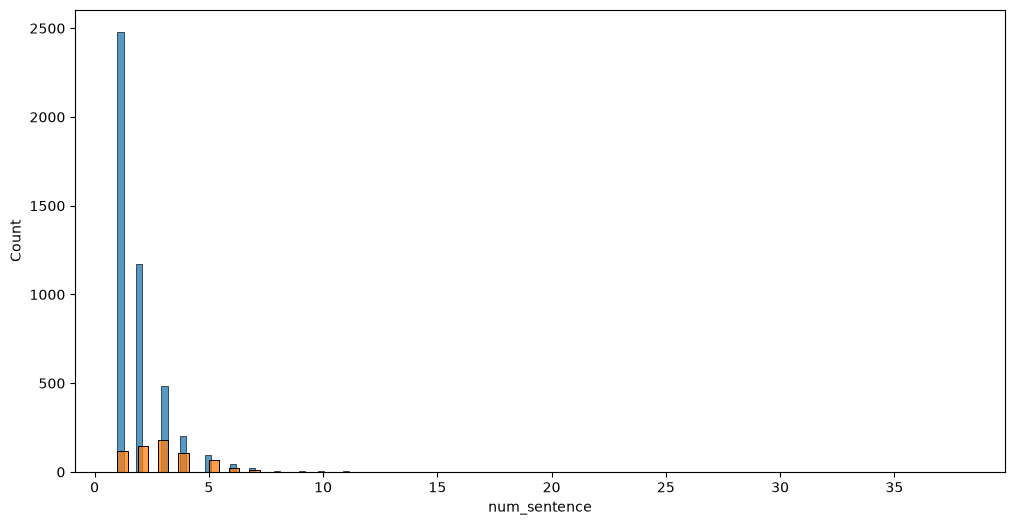

In [137]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target']==0]['num_sentence'])
sns.histplot(df[df['target']==1]['num_sentence'])

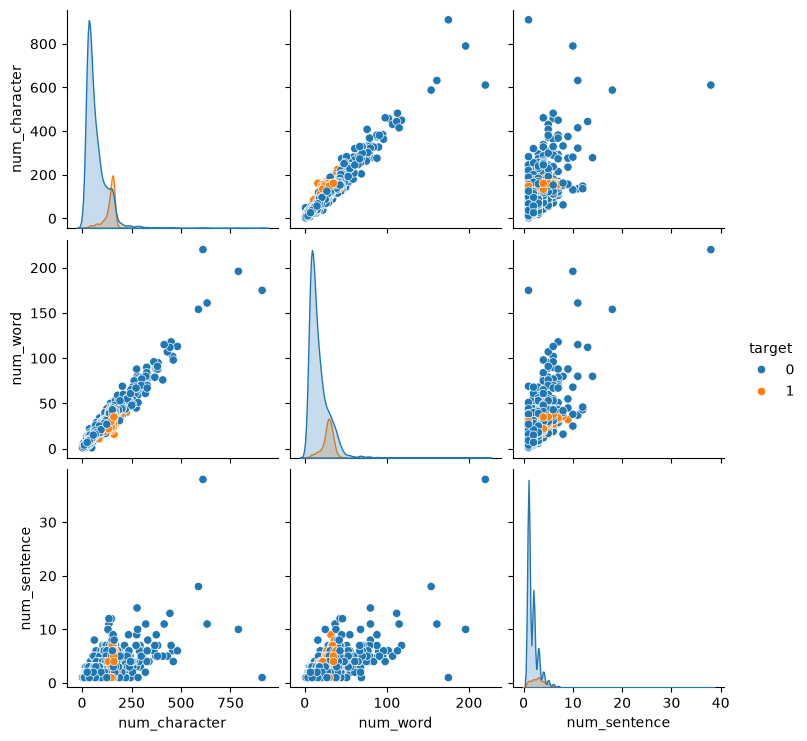

In [138]:
sns.pairplot(df,hue='target')

<Axes: >

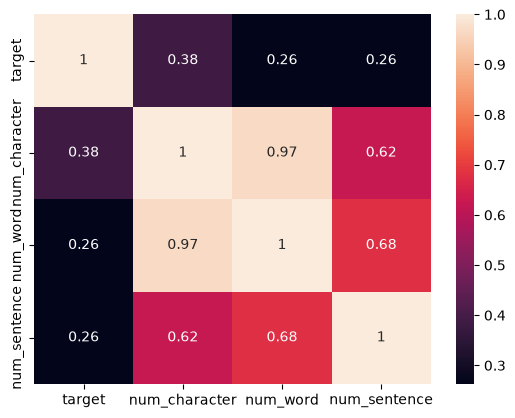

In [145]:
sns.heatmap(df[['target','num_character', 'num_word', 'num_sentence']].corr(), annot = True)

## 3. Data Preprocessing
- Lower case
- Tokenization
- Removing special character
- Removing stop words and punctuation
- Stemming

In [161]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [162]:
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [163]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [171]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('dances')

'danc'

In [172]:
def transfrom_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)

    y = []
    for i in text:
        if i.isalnum():
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))
    
    return " ".join(y)

In [174]:
transfrom_text(df['text'][0])

'go jurong point crazi avail bugi n great world la e buffet cine got amor wat'

In [175]:
df["transformed_text"] = df['text'].apply(transfrom_text)

In [185]:
from wordcloud import WordCloud
wc = WordCloud(width = 500, height = 500, min_font_size = 10, background_color = 'black')


In [186]:
spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=" "))

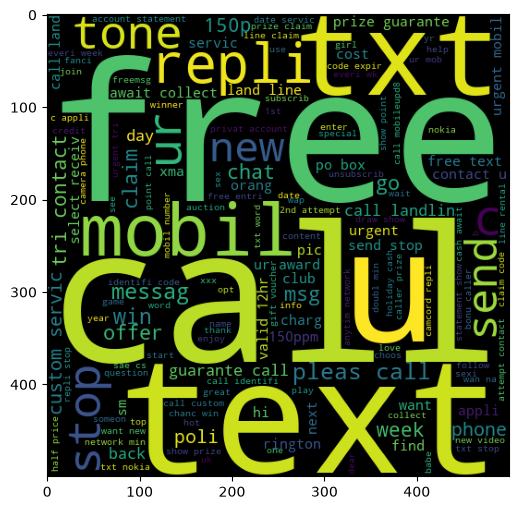

In [187]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

In [188]:
ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=" "))

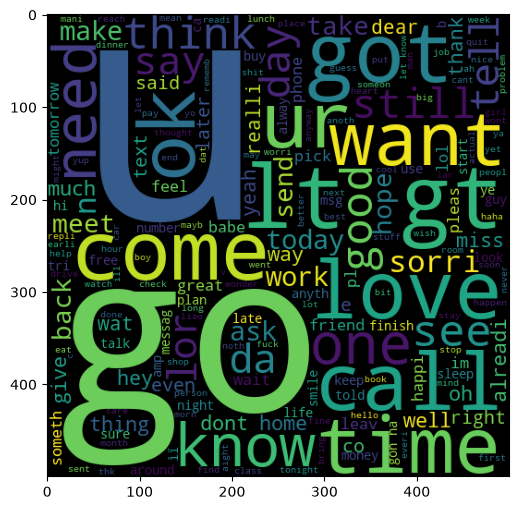

In [189]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

In [191]:
spam_corpus = []
for msg in df[df['target']==1]['transformed_text'].tolist():
    for word in msg.split(" "):
        spam_corpus.append(word)

In [192]:
len(spam_corpus)

9939

In [194]:
from collections import Counter
count = Counter(spam_corpus).most_common(30)

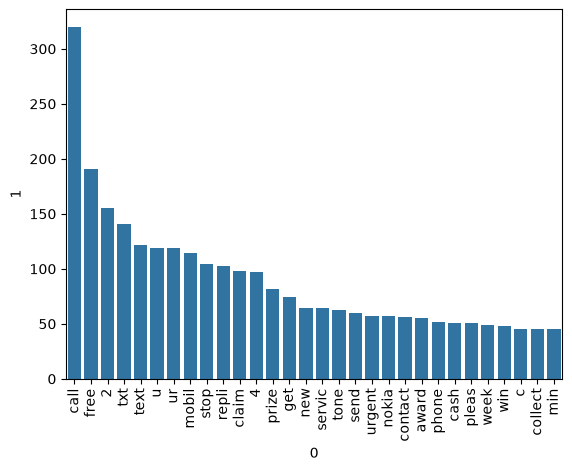

In [207]:
sns.barplot( x = pd.DataFrame(count)[0], y = pd.DataFrame(count)[1])
plt.xticks(rotation = 'vertical')
plt.show()

In [209]:
ham_corpus = []
for msg in df[df['target']==0]['transformed_text'].tolist():
    for word in msg.split(" "):
        ham_corpus.append(word)

In [210]:
count_ham = Counter(ham_corpus).most_common(30)

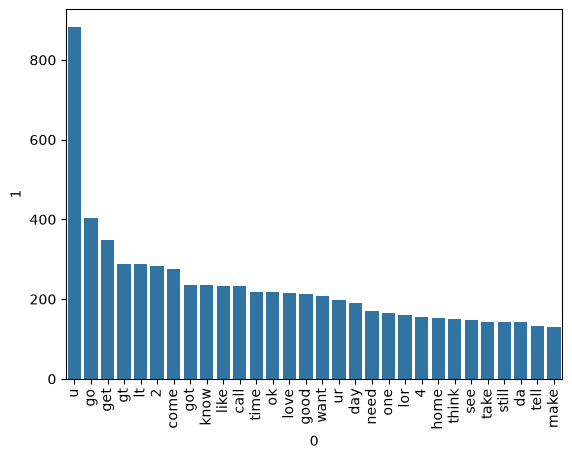

In [246]:
sns.barplot( x = pd.DataFrame(count_ham)[0], y = pd.DataFrame(count_ham)[1])
plt.xticks(rotation = 'vertical')
plt.show()

## 4. Model Building

In [272]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)

In [273]:
X = cv.fit_transform(df['transformed_text']).toarray()

In [274]:
X.shape

(5169, 6708)

In [275]:
y = df['target'].values

In [276]:
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [277]:
from sklearn.model_selection import train_test_split


In [278]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=2)

In [279]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix


In [280]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [281]:
gnb.fit(X_train, y_train)
y_pred3 = gnb.predict(X_test)
print(accuracy_score(y_test, y_pred3))
print(confusion_matrix(y_test, y_pred3))
print(precision_score(y_test, y_pred3))

0.8800773694390716
[[792 104]
 [ 20 118]]
0.5315315315315315


In [282]:
mnb.fit(X_train, y_train)
y_pred1 = mnb.predict(X_test)
print(accuracy_score(y_test, y_pred1))
print(confusion_matrix(y_test, y_pred1))
print(precision_score(y_test, y_pred1))

0.9642166344294004
[[871  25]
 [ 12 126]]
0.8344370860927153


In [283]:
bnb.fit(X_train, y_train)
y_pred2 = bnb.predict(X_test)
print(accuracy_score(y_test, y_pred2))
print(confusion_matrix(y_test, y_pred2))
print(precision_score(y_test, y_pred2))

0.9700193423597679
[[893   3]
 [ 28 110]]
0.9734513274336283


In [284]:
# countVectorization -> bnb

In [285]:
X = tfidf.fit_transform(df['transformed_text']).toarray()

In [286]:
y = df['target'].values

In [287]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=2)

In [288]:
gnb.fit(X_train, y_train)
y_pred4= gnb.predict(X_test)
print(accuracy_score(y_test, y_pred4))
print(confusion_matrix(y_test, y_pred4))
print(precision_score(y_test, y_pred4))

0.874274661508704
[[790 106]
 [ 24 114]]
0.5181818181818182


In [289]:
mnb.fit(X_train, y_train)
y_pred5 = mnb.predict(X_test)
print(accuracy_score(y_test, y_pred5))
print(confusion_matrix(y_test, y_pred5))
print(precision_score(y_test, y_pred5))

0.9709864603481625
[[896   0]
 [ 30 108]]
1.0


In [290]:
bnb.fit(X_train, y_train)
y_pred6 = bnb.predict(X_test)
print(accuracy_score(y_test, y_pred6))
print(confusion_matrix(y_test, y_pred6))
print(precision_score(y_test, y_pred6))

0.9835589941972921
[[895   1]
 [ 16 122]]
0.991869918699187


In [291]:
# Tfidf -> mnb

In [292]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [293]:
svc = SVC(kernel='sigmoid',gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth = 5)
lrc = LogisticRegression(solver = 'liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)


In [294]:
clfs = {
    'SVC' : svc,
    'KN' : knc, 
    'NB': mnb, 
    'DT': dtc, 
    'LR': lrc, 
    'RF': rfc, 
    'AdaBoost': abc, 
    'BgC': bc, 
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [295]:

def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    
    return accuracy,precision

In [296]:
train_classifier(svc,X_train,y_train,X_test,y_test)

(0.9758220502901354, 0.9747899159663865)

In [297]:
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():
    
    current_accuracy,current_precision = train_classifier(clf, X_train,y_train,X_test,y_test)
    
    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.9758220502901354
Precision -  0.9747899159663865
For  KN
Accuracy -  0.9052224371373307
Precision -  1.0
For  NB
Accuracy -  0.9709864603481625
Precision -  1.0
For  DT
Accuracy -  0.9303675048355899
Precision -  0.83
For  LR
Accuracy -  0.9555125725338491
Precision -  0.96


e:\Projects\Email_spam_detector\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
e:\Projects\Email_spam_detector\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


For  RF
Accuracy -  0.9738878143133463
Precision -  0.9826086956521739
For  AdaBoost
Accuracy -  0.9216634429400387
Precision -  0.8202247191011236
For  BgC
Accuracy -  0.9584139264990329
Precision -  0.8682170542635659
For  ETC
Accuracy -  0.9748549323017408
Precision -  0.9745762711864406
For  GBDT
Accuracy -  0.9506769825918762
Precision -  0.9306930693069307
For  xgb
Accuracy -  0.9700193423597679
Precision -  0.9572649572649573


In [270]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)


In [271]:
performance_df

,Algorithm,Accuracy,Precision
1,KN,0.900387,1.000000
2,NB,0.959381,1.000000
5,RF,0.971954,1.000000
8,ETC,0.972921,0.982456
0,SVC,0.972921,0.974138
10,xgb,0.970986,0.942623
4,LR,0.951644,0.940000
9,GBDT,0.951644,0.923077
7,BgC,0.958414,0.862595
3,DT,0.936170,0.846154


## 5. Model improve

In [299]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_max_ft_3000':accuracy_scores,'Precision_max_ft_3000':precision_scores}).sort_values('Precision_max_ft_3000',ascending=False)

In [300]:

new_df = performance_df.merge(temp_df,on='Algorithm')

In [301]:
new_df

,Algorithm,Accuracy,Precision,Accuracy_max_ft_3000,Precision_max_ft_3000
0,KN,0.900387,1.000000,0.905222,1.000000
1,NB,0.959381,1.000000,0.970986,1.000000
2,RF,0.971954,1.000000,0.973888,0.982609
3,ETC,0.972921,0.982456,0.974855,0.974576
4,SVC,0.972921,0.974138,0.975822,0.974790
5,xgb,0.970986,0.942623,0.970019,0.957265
6,LR,0.951644,0.940000,0.955513,0.960000
7,GBDT,0.951644,0.923077,0.950677,0.930693
8,BgC,0.958414,0.862595,0.958414,0.868217
9,DT,0.936170,0.846154,0.930368,0.830000
